# Stabilizing SCENT via L2 Regularization, Logit-Adjusted Margins, and Linear Warmup

**CSCE 726 Project — Harsh**

This notebook implements the full factorial ablation study from the proposal.
It builds on the provided SCENT/SOX baseline notebook.

## 0. Prerequisites (run once)

In [1]:
!gdown --folder 'https://drive.google.com/drive/folders/10cY2Azqz9Gnci-r4fXcGIpH_e5YaKXH_?usp=sharing' -O ./features
!git clone https://github.com/xywei00/LibAUC.git -b xiyuan/1.5.0_dev
!pip install ./LibAUC

Retrieving folder contents
Retrieving folder 1cvVXLotOAQsFopyB03LZxA9yuNRXxl2I treeoflife10m_subset
Retrieving folder 1fcoocWaeJZtB1NhC1aXgBp8NCjPrFZTU train
Processing file 1wyrbWXNPjUMBWJvI7B7QEraGkXts3B1t features.pt
Processing file 16U77_XulkLuPdN8gbzy5ZkWZKeoVRBmz labels.pt
Retrieving folder 1Xv0JfbkJpj7boGVQHnOaoNWipAn85uuc val
Processing file 1E8iB9DtYQKRW42WwwOe5Ce7yIDtMk7rY features.pt
Processing file 1wnzdt2tYw1bpdf4016EREKr1k5kMh7rf labels.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1wyrbWXNPjUMBWJvI7B7QEraGkXts3B1t
From (redirected): https://drive.google.com/uc?id=1wyrbWXNPjUMBWJvI7B7QEraGkXts3B1t&confirm=t&uuid=48ffa655-171b-40c0-bdfe-956ee864980f
To: /content/features/treeoflife10m_subset/train/features.pt
100% 1.56G/1.56G [00:23<00:00, 65.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=16U77_XulkLuPdN8gbzy5ZkWZKeoVRBmz
To: /content/fea

## 1. Imports and Constants

In [2]:
import os
import logging
import pathlib
import json
import sys
import random
import math
import copy
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR, SequentialLR

from libauc.losses import EntLossClassification
from libauc.optimizers import SCENT

# ── Constants ──
DATA_DIR = "./features/treeoflife10m_subset"
ROOT_OUT_DIR = "./outputs/"
SEED = 2026
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
FEATURE_DIM = 512
NUM_CLASSES = 163002
DATA_SIZE = 762654
EPOCHS = 20
BATCH_SIZE = 128
SAVE_FREQUENCY = 5

print(f"Device: {DEVICE}")

Device: cuda


## 2. Utilities (unchanged from baseline)

In [3]:
class FeaturesDataset(Dataset):
    def __init__(self, features_path: str, labels_path: str):
        self.features = torch.load(features_path)
        self.labels = torch.load(labels_path)
        assert self.features.shape[0] == self.labels.shape[0]

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], idx


def setup_logging(out_log_file=None):
    logging.root.setLevel(level=logging.INFO)
    for logger in [logging.getLogger(name) for name in logging.root.manager.loggerDict]:
        logger.setLevel(level=logging.INFO)
    formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s', datefmt='%Y-%m-%d,%H:%M:%S')
    if out_log_file is not None:
        logging.root.addHandler(logging.FileHandler(out_log_file))
    for handler in logging.root.handlers:
        handler.setFormatter(formatter)


def build_dataloaders(root_data_dir, batch_size):
    loaders = []
    for split, shuffle in [("train", True), ("val", False), ("test", False)]:
        data_dir = os.path.join(root_data_dir, split)
        if not os.path.exists(data_dir):
            if split in ("train", "val"):
                raise FileNotFoundError(f"{data_dir} does not exist.")
            loaders.append(None)
            continue
        ds = FeaturesDataset(os.path.join(data_dir, "features.pt"),
                             os.path.join(data_dir, "labels.pt"))
        loaders.append(DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0))
    return loaders[0], loaders[1], loaders[2]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


setup_logging()

## 3. Compute Class Priors

We compute $\pi_k = n_k / n$ from the training labels and store $\log \pi_k$ for LA-CERM.

In [4]:
train_labels = torch.load(os.path.join(DATA_DIR, "train", "labels.pt"))
class_counts = torch.bincount(train_labels.long(), minlength=NUM_CLASSES).float()
# Add smoothing to avoid log(0) for classes with 0 training samples
class_priors = (class_counts + 1e-8) / (class_counts.sum() + NUM_CLASSES * 1e-8)
log_priors = torch.log(class_priors)  # shape: (K,)

# Diagnostic: feature norm statistics
train_features = torch.load(os.path.join(DATA_DIR, "train", "features.pt"))
feat_norms = torch.norm(train_features, dim=1)
print(f"Feature norm stats: mean={feat_norms.mean():.4f}, std={feat_norms.std():.4f}, "
      f"min={feat_norms.min():.4f}, max={feat_norms.max():.4f}")
print(f"Class count stats: min={class_counts.min():.0f}, max={class_counts.max():.0f}, "
      f"median={class_counts.median():.0f}, zero_count={(class_counts == 0).sum().item()}")
del train_features  # free memory

Feature norm stats: mean=1.0000, std=0.0000, min=1.0000, max=1.0000
Class count stats: min=0, max=102192, median=0, zero_count=84502


## 4. Model: LinearClassifier with LA-CERM Support

We extend the baseline `LinearClassifier` to optionally apply the logit-adjusted margin shift.
The log-prior offset is registered as a buffer so it is saved/loaded with the model.

In [5]:
class LinearClassifierLA(nn.Module):
    """Linear classifier with optional Logit-Adjusted margin for LA-CERM.

    When `tau > 0`, the forward pass adds tau * log(pi_zeta / pi_yi) to the
    margin score s_i(w; zeta), implementing Eq.(1) from the proposal.
    The weight gradient direction is unchanged; only the exponent in the
    SCENT dual update is re-scaled.
    """

    def __init__(self, feature_dim: int, num_classes: int,
                 log_priors: Optional[torch.Tensor] = None, tau: float = 0.0):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.tau = tau
        self.fc = nn.Linear(feature_dim, num_classes, bias=False)
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)

        # Register log_priors as a buffer (not a parameter — no gradients)
        if log_priors is not None:
            self.register_buffer('log_priors', log_priors.clone())
        else:
            self.register_buffer('log_priors', torch.zeros(num_classes))

    def forward(self, x: torch.Tensor, labels: torch.Tensor,
                classes: torch.Tensor | str | None = None) -> torch.Tensor:
        """Compute (optionally logit-adjusted) margin logits.

        The margin is: s_i(w; zeta) = h(x_i)^T w_zeta - h(x_i)^T w_yi
        With LA-CERM:  s_i^LA     = s_i + tau * (log pi_zeta - log pi_yi)
        """
        w_pos = self.fc.weight[labels]  # (B, D)

        mask = None
        if isinstance(classes, str):
            assert classes == "all"
            w_sampled = self.fc.weight
            sampled_indices = None  # all classes
        elif isinstance(classes, torch.Tensor):
            w_sampled = self.fc.weight[classes]
            sampled_indices = classes
        elif classes is None:
            unique_labels = torch.unique(labels)  # (K_batch,)
            w_sampled = self.fc.weight[unique_labels]  # (K_batch, D)
            mask = (labels.unsqueeze(1) == unique_labels.unsqueeze(0))  # (B, K_batch)
            sampled_indices = unique_labels
        else:
            raise ValueError(f"Unknown classes type: {type(classes)}")

        # Standard margin: h(x)^T w_zeta - h(x)^T w_yi
        logits = x @ w_sampled.T - torch.sum(torch.mul(x, w_pos), dim=1, keepdim=True)

        # LA-CERM: add tau * (log pi_zeta - log pi_yi)
        if self.tau > 0:
            log_prior_yi = self.log_priors[labels]  # (B,)
            if sampled_indices is not None:
                log_prior_zeta = self.log_priors[sampled_indices]  # (K_batch,)
            else:
                log_prior_zeta = self.log_priors  # (K,)
            # Broadcast: (B, K_batch) += tau * ((1, K_batch) - (B, 1))
            logits = logits + self.tau * (log_prior_zeta.unsqueeze(0) - log_prior_yi.unsqueeze(1))

        if mask is not None:
            logits.masked_fill_(mask.to(logits.device), float("-inf"))

        return logits

## 5. Learning Rate Scheduler: Linear Warmup + Cosine Annealing

In [6]:
def build_lr_scheduler(optimizer, epochs, warmup_epochs=0):
    """Build a scheduler: optional linear warmup followed by cosine annealing.

    If warmup_epochs == 0, this is identical to the baseline CosineAnnealingLR.
    """
    if warmup_epochs <= 0:
        return CosineAnnealingLR(optimizer, T_max=epochs)

    # Phase 1: linear warmup from 0 to base_lr over warmup_epochs
    warmup_scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: epoch / warmup_epochs if epoch < warmup_epochs else 1.0
    )
    # Phase 2: cosine annealing over the remaining epochs
    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs - warmup_epochs
    )
    # Compose them
    return SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )

## 6. Training and Evaluation Functions

These are nearly identical to the baseline, with two additions:
- L2 regularization is handled via PyTorch's `weight_decay` parameter in the optimizer
- Post-hoc logit adjustment at evaluation time for Config 10

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    total = 0
    for i, batch in enumerate(loader):
        feats, labels, indices = batch
        feats = feats.to(device)
        logits = model(feats, labels)
        loss_dict = criterion(logits, indices)
        loss = loss_dict["loss"]

        # Track cross-entropy for logging (no grad)
        with torch.no_grad():
            model.eval()
            labels_dev = labels.to(device, dtype=torch.long)
            ce_loss = F.cross_entropy(model.fc(feats), labels_dev)
            model.train()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += ce_loss.item() * feats.size(0)
        total += feats.size(0)

        if i % 200 == 0:
            log_str = f"  Batch {i}/{len(loader)}:"
            for key, value in loss_dict.items():
                log_str += f" {key}={value.item():.4f}"
            log_str += f" ce={ce_loss.item():.4f}"
            logging.info(log_str)

    return total_loss / total


@torch.no_grad()
def evaluate(model, loader, device, posthoc_log_priors=None, posthoc_tau=0.0):
    """Evaluate model. Returns (loss, top1_acc, top5_acc).

    If posthoc_log_priors is provided, applies post-hoc logit adjustment:
        adjusted_logit_k = logit_k + posthoc_tau * log(pi_k)
    """
    model.eval()
    total_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    if posthoc_log_priors is not None:
        posthoc_shift = (posthoc_tau * posthoc_log_priors).to(device)  # (K,)
    else:
        posthoc_shift = None

    for i, batch in enumerate(loader):
        feats, labels, _ = batch
        feats = feats.to(device)
        labels = labels.to(device, dtype=torch.long)

        logits = model.fc(feats)  # (B, K) — raw logits for evaluation

        if posthoc_shift is not None:
            logits = logits + posthoc_shift.unsqueeze(0)

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item() * feats.size(0)

        # Top-1
        preds = logits.argmax(dim=1)
        correct_top1 += (preds == labels).sum().item()

        # Top-5
        _, top5_preds = logits.topk(5, dim=1)
        correct_top5 += (top5_preds == labels.unsqueeze(1)).any(dim=1).sum().item()

        total += feats.size(0)

    return total_loss / total, correct_top1 / total, correct_top5 / total


def get_weight_norm_stats(model):
    """Return weight norm diagnostics."""
    with torch.no_grad():
        w = model.fc.weight
        norms = torch.norm(w, dim=1)  # (K,)
        return {
            "w_norm_mean": norms.mean().item(),
            "w_norm_std": norms.std().item(),
            "w_norm_min": norms.min().item(),
            "w_norm_max": norms.max().item(),
        }

## 7. Experiment Configuration

Each config is a dataclass specifying the algorithm, whether L2 reg / LA-CERM / warmup is active,
and the relevant hyperparameters.

In [8]:
@dataclass
class ExperimentConfig:
    name: str
    is_scent: bool = True          # True=SCENT, False=SOX
    lr: float = 0.002
    momentum: float = 0.9
    weight_decay: float = 0.0      # L2 regularization strength
    la_tau: float = 0.0            # LA-CERM temperature (0 = disabled)
    warmup_epochs: int = 0         # 0 = no warmup
    posthoc_tau: float = 0.0       # post-hoc logit adjustment at eval (0 = disabled)
    # SOX-specific
    sox_gamma: float = 0.6
    # SCENT-specific
    alpha: float = 0.0
    alpha_multiplier: float = 0.03


# ── Hyperparameter choices ──
# These can be tuned via the sweep in April 13-15
L2_LAMBDA = 1e-4       # weight decay strength
LA_TAU = 1.0           # logit adjustment temperature
WARMUP_EP = 2          # warmup epochs

# ── Full factorial ablation (Table 1 from the proposal) ──
CONFIGS = [
    # Config 1: SOX baseline
    ExperimentConfig(
        name="config01_sox_baseline",
        is_scent=False, lr=0.001,
    ),
    # Config 2: SCENT baseline
    ExperimentConfig(
        name="config02_scent_baseline",
    ),
    # Config 3: SCENT + L2 only
    ExperimentConfig(
        name="config03_scent_l2",
        weight_decay=L2_LAMBDA,
    ),
    # Config 4: SCENT + LA-CERM only
    ExperimentConfig(
        name="config04_scent_la",
        la_tau=LA_TAU,
    ),
    # Config 5: SCENT + Warmup only
    ExperimentConfig(
        name="config05_scent_warmup",
        warmup_epochs=WARMUP_EP,
    ),
    # Config 6: SCENT + L2 + LA-CERM
    ExperimentConfig(
        name="config06_scent_l2_la",
        weight_decay=L2_LAMBDA, la_tau=LA_TAU,
    ),
    # Config 7: SCENT + L2 + Warmup
    ExperimentConfig(
        name="config07_scent_l2_warmup",
        weight_decay=L2_LAMBDA, warmup_epochs=WARMUP_EP,
    ),
    # Config 8: SCENT + LA-CERM + Warmup
    ExperimentConfig(
        name="config08_scent_la_warmup",
        la_tau=LA_TAU, warmup_epochs=WARMUP_EP,
    ),
    # Config 9: SCENT + L2 + LA-CERM + Warmup (unified)
    ExperimentConfig(
        name="config09_scent_unified",
        weight_decay=L2_LAMBDA, la_tau=LA_TAU, warmup_epochs=WARMUP_EP,
    ),
    # Config 10: Same training as Config 7, post-hoc LA at eval
    # (trains identically to config07; only evaluation differs)
    ExperimentConfig(
        name="config10_scent_posthoc",
        weight_decay=L2_LAMBDA, warmup_epochs=WARMUP_EP,
        posthoc_tau=LA_TAU,
    ),
]

print(f"Total configurations: {len(CONFIGS)}")
for c in CONFIGS:
    flags = []
    if not c.is_scent: flags.append("SOX")
    else: flags.append("SCENT")
    if c.weight_decay > 0: flags.append(f"L2={c.weight_decay}")
    if c.la_tau > 0: flags.append(f"LA(tau={c.la_tau})")
    if c.warmup_epochs > 0: flags.append(f"WU={c.warmup_epochs}ep")
    if c.posthoc_tau > 0: flags.append(f"PostHoc(tau={c.posthoc_tau})")
    print(f"  {c.name}: {' + '.join(flags)}")

Total configurations: 10
  config01_sox_baseline: SOX
  config02_scent_baseline: SCENT
  config03_scent_l2: SCENT + L2=0.0001
  config04_scent_la: SCENT + LA(tau=1.0)
  config05_scent_warmup: SCENT + WU=2ep
  config06_scent_l2_la: SCENT + L2=0.0001 + LA(tau=1.0)
  config07_scent_l2_warmup: SCENT + L2=0.0001 + WU=2ep
  config08_scent_la_warmup: SCENT + LA(tau=1.0) + WU=2ep
  config09_scent_unified: SCENT + L2=0.0001 + LA(tau=1.0) + WU=2ep
  config10_scent_posthoc: SCENT + L2=0.0001 + WU=2ep + PostHoc(tau=1.0)


## 8. Main Training Loop

This function runs a single experiment configuration end-to-end.

In [9]:
def run_experiment(cfg: ExperimentConfig):
    """Run a single experiment configuration."""
    logging.info(f"\n{'='*60}")
    logging.info(f"Starting experiment: {cfg.name}")
    logging.info(f"Config: {cfg}")
    logging.info(f"{'='*60}")

    out_dir = pathlib.Path(ROOT_OUT_DIR) / cfg.name
    os.makedirs(out_dir / "checkpoints", exist_ok=True)

    set_seed(SEED)
    train_loader, val_loader, test_loader = build_dataloaders(DATA_DIR, BATCH_SIZE)

    # ── Model ──
    model = LinearClassifierLA(
        feature_dim=FEATURE_DIM,
        num_classes=NUM_CLASSES,
        log_priors=log_priors if cfg.la_tau > 0 else None,
        tau=cfg.la_tau,
    ).to(DEVICE)

    # ── Optimizer ──
    # The SCENT optimizer from LibAUC uses Momentum SGD internally.
    # weight_decay here is standard L2 regularization (not decoupled).
    optimizer = SCENT(
        model.parameters(),
        lr=cfg.lr,
        momentum=cfg.momentum,
        weight_decay=cfg.weight_decay,
    )

    # ── LR Scheduler ──
    lr_scheduler = build_lr_scheduler(optimizer, EPOCHS, warmup_epochs=cfg.warmup_epochs)

    # ── Loss ──
    if cfg.is_scent:
        criterion = EntLossClassification(
            data_size=DATA_SIZE,
            alpha=cfg.alpha,
            is_scent=True,
            alpha_multiplier=cfg.alpha_multiplier,
        )
    else:
        criterion = EntLossClassification(
            data_size=DATA_SIZE,
            gamma=cfg.sox_gamma,
            is_scent=False,
        )

    # ── Training ──
    best_val_acc = 0.0
    best_test_acc = 0.0
    best_test_loss = float("inf")
    best_test_top5 = 0.0
    all_results = []

    for epoch in range(1, EPOCHS + 1):
        current_lr = lr_scheduler.get_last_lr()[0]
        logging.info(f"[{cfg.name}] Epoch {epoch}/{EPOCHS}, lr={current_lr:.6f}")

        if hasattr(criterion, "adjust_gamma"):
            criterion.adjust_gamma(epoch, EPOCHS)

        ce_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        lr_scheduler.step()

        # Weight norm diagnostics
        w_stats = get_weight_norm_stats(model)

        # ── Evaluation ──
        # Standard evaluation (no post-hoc adjustment)
        val_loss, val_top1, val_top5 = evaluate(model, val_loader, DEVICE)

        # Post-hoc evaluation if configured
        if cfg.posthoc_tau > 0:
            val_loss_ph, val_top1_ph, val_top5_ph = evaluate(
                model, val_loader, DEVICE,
                posthoc_log_priors=log_priors,
                posthoc_tau=cfg.posthoc_tau,
            )
            # Use post-hoc results for model selection
            val_acc_for_selection = val_top1_ph
        else:
            val_acc_for_selection = val_top1

        if val_acc_for_selection > best_val_acc:
            best_val_acc = val_acc_for_selection
            logging.info(f"  New best val acc: {best_val_acc:.4f}")
            if test_loader is not None:
                if cfg.posthoc_tau > 0:
                    best_test_loss, best_test_acc, best_test_top5 = evaluate(
                        model, test_loader, DEVICE,
                        posthoc_log_priors=log_priors,
                        posthoc_tau=cfg.posthoc_tau,
                    )
                else:
                    best_test_loss, best_test_acc, best_test_top5 = evaluate(
                        model, test_loader, DEVICE,
                    )

        # ── Logging ──
        result = {
            "epoch": epoch,
            "lr": current_lr,
            "train_ce_loss": ce_loss,
            "val_loss": val_loss,
            "val_top1": val_top1,
            "val_top5": val_top5,
            "best_val_acc": best_val_acc,
            **w_stats,
        }
        if cfg.posthoc_tau > 0:
            result["val_top1_posthoc"] = val_top1_ph
            result["val_top5_posthoc"] = val_top5_ph
        if test_loader is not None:
            result["best_test_acc"] = best_test_acc
            result["best_test_loss"] = best_test_loss
            result["best_test_top5"] = best_test_top5

        all_results.append(result)
        with open(out_dir / f"eval_{cfg.name}.jsonl", "a") as f:
            f.write(json.dumps(result) + "\n")

        logging.info(
            f"  ce={ce_loss:.4f} val_loss={val_loss:.4f} "
            f"top1={val_top1:.4f} top5={val_top5:.4f} "
            f"w_norm=[{w_stats['w_norm_min']:.3f}, {w_stats['w_norm_max']:.3f}]"
        )

        # Save checkpoint
        if epoch % SAVE_FREQUENCY == 0 or epoch == EPOCHS:
            save_dict = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "config": cfg.__dict__,
            }
            if hasattr(criterion, "nu"):
                save_dict["criterion_nu"] = criterion.nu.cpu()
            torch.save(save_dict, out_dir / "checkpoints" / f"epoch_{epoch}.pt")

    logging.info(f"\n[{cfg.name}] FINAL: best_val={best_val_acc:.4f} "
                 f"best_test={best_test_acc:.4f} best_test_top5={best_test_top5:.4f}")

    return all_results

## 9. Run All Experiments

**Note:** Config 10 trains identically to Config 7 (SCENT + L2 + Warmup).
To save compute, we can skip training Config 10 and just re-evaluate Config 7's
model with post-hoc adjustment. The code below handles both cases.

In [10]:
# To run a subset, slice CONFIGS, e.g.:
#   CONFIGS_TO_RUN = CONFIGS[1:3]  # just SCENT baseline + L2
# To run everything:
CONFIGS_TO_RUN = CONFIGS

all_experiment_results = {}
for cfg in CONFIGS_TO_RUN:
    results = run_experiment(cfg)
    all_experiment_results[cfg.name] = results

Streaming output truncated to the last 5000 lines.
2026-04-29,22:43:09 | INFO |   Batch 1000/5959: loss=0.9275 ce=11.0151
2026-04-29,22:43:11 | INFO |   Batch 1200/5959: loss=0.9548 ce=11.3928
2026-04-29,22:43:13 | INFO |   Batch 1400/5959: loss=0.8971 ce=10.6283
2026-04-29,22:43:15 | INFO |   Batch 1600/5959: loss=0.9345 ce=11.0626
2026-04-29,22:43:18 | INFO |   Batch 1800/5959: loss=0.9173 ce=10.8312
2026-04-29,22:43:20 | INFO |   Batch 2000/5959: loss=0.8992 ce=10.6827
2026-04-29,22:43:22 | INFO |   Batch 2200/5959: loss=0.8759 ce=10.3998
2026-04-29,22:43:25 | INFO |   Batch 2400/5959: loss=0.8914 ce=10.5931
2026-04-29,22:43:27 | INFO |   Batch 2600/5959: loss=0.9156 ce=10.9320
2026-04-29,22:43:29 | INFO |   Batch 2800/5959: loss=0.9261 ce=10.9369
2026-04-29,22:43:32 | INFO |   Batch 3000/5959: loss=0.9317 ce=11.1391
2026-04-29,22:43:34 | INFO |   Batch 3200/5959: loss=0.9239 ce=11.0558
2026-04-29,22:43:36 | INFO |   Batch 3400/5959: loss=0.9198 ce=10.9432
2026-04-29,22:43:38 | INFO

## 10. Results Summary and Visualization

In [11]:
import matplotlib.pyplot as plt

def load_results(config_name):
    """Load results from JSONL file."""
    path = pathlib.Path(ROOT_OUT_DIR) / config_name / f"eval_{config_name}.jsonl"
    results = []
    if path.exists():
        with open(path) as f:
            for line in f:
                results.append(json.loads(line))
    return results


# ── Summary Table ──
print(f"{'Config':<35} {'Best Val Top1':>13} {'Best Val Top5':>13} {'Best Test Top1':>14} {'Final CE':>10}")
print("─" * 90)
for cfg in CONFIGS:
    results = load_results(cfg.name)
    if not results:
        print(f"{cfg.name:<35} {'(not run)':>13}")
        continue
    best_val = max(r.get('val_top1', 0) for r in results)
    best_val_top5 = max(r.get('val_top5', 0) for r in results)
    best_test = max(r.get('best_test_acc', 0) for r in results)
    final_ce = results[-1].get('train_ce_loss', 0)
    print(f"{cfg.name:<35} {best_val:>13.4f} {best_val_top5:>13.4f} {best_test:>14.4f} {final_ce:>10.4f}")

Config                              Best Val Top1 Best Val Top5 Best Test Top1   Final CE
──────────────────────────────────────────────────────────────────────────────────────────
config01_sox_baseline                      0.2008        0.3341         0.0000     9.7348
config02_scent_baseline                    0.2643        0.3653         0.0000     9.2379
config03_scent_l2                          0.1349        0.1512         0.0000    10.6889
config04_scent_la                          0.1533        0.2158         0.0000    10.5881
config05_scent_warmup                      0.2636        0.3635         0.0000     9.4036
config06_scent_l2_la                       0.1192        0.1286         0.0000    11.3260
config07_scent_l2_warmup                   0.1343        0.1509         0.0000    10.8739
config08_scent_la_warmup                   0.1376        0.1884         0.0000    10.7525
config09_scent_unified                     0.1151        0.1219         0.0000    11.3798
config10_

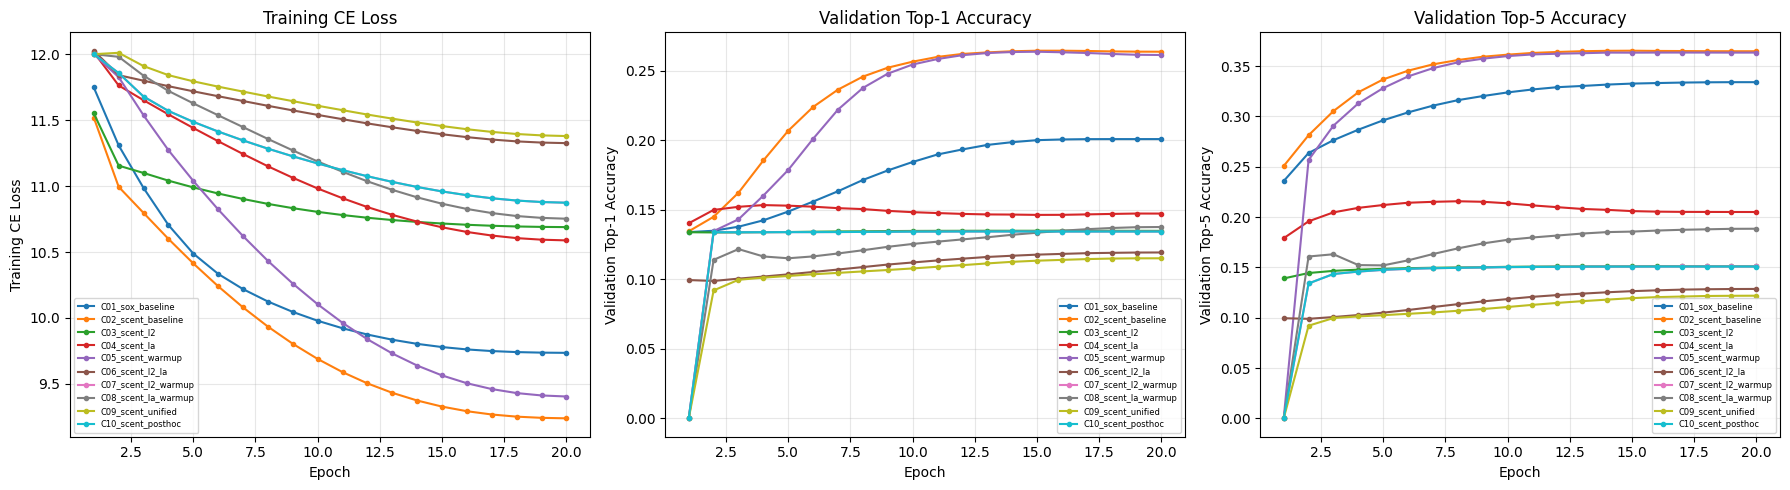

In [12]:
# ── Learning Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ("train_ce_loss", "Training CE Loss"),
    ("val_top1", "Validation Top-1 Accuracy"),
    ("val_top5", "Validation Top-5 Accuracy"),
]

for ax, (metric_key, metric_name) in zip(axes, metrics):
    for cfg in CONFIGS:
        results = load_results(cfg.name)
        if not results:
            continue
        epochs_list = [r["epoch"] for r in results]
        values = [r.get(metric_key, 0) for r in results]
        ax.plot(epochs_list, values, label=cfg.name.replace("config", "C"), marker='.')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROOT_OUT_DIR, "learning_curves.png"), dpi=150)
plt.show()

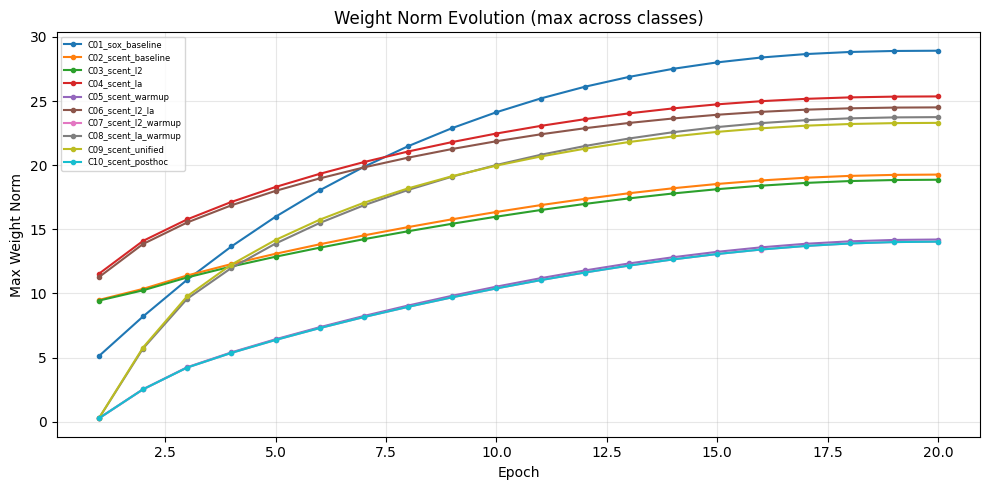

In [13]:
# ── Weight Norm Evolution ──
fig, ax = plt.subplots(figsize=(10, 5))
for cfg in CONFIGS:
    results = load_results(cfg.name)
    if not results:
        continue
    epochs_list = [r["epoch"] for r in results]
    w_max = [r.get("w_norm_max", 0) for r in results]
    ax.plot(epochs_list, w_max, label=cfg.name.replace("config", "C"), marker='.')

ax.set_xlabel("Epoch")
ax.set_ylabel("Max Weight Norm")
ax.set_title("Weight Norm Evolution (max across classes)")
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_OUT_DIR, "weight_norms.png"), dpi=150)
plt.show()